# Лабораторная работа 5-6
Выделить фрукты на изображении

In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = cv.imread('oranges.jpg')
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

gs = plt.GridSpec(1, 2)

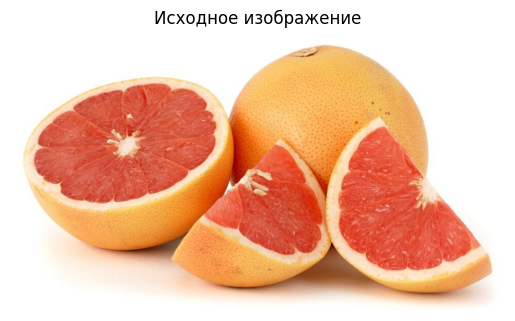

In [27]:
plt.figure()
plt.title("Исходное изображение")
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

## Преобразование в HSV

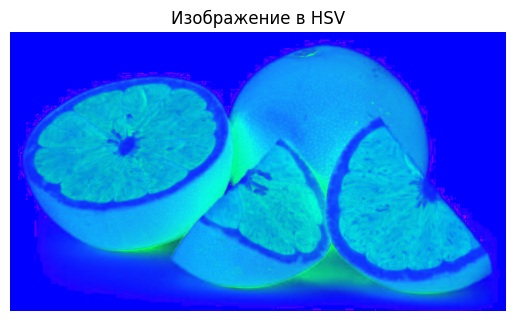

In [28]:
image_hsv = cv.cvtColor(image_rgb, cv.COLOR_RGB2HSV)

plt.figure()
plt.title("Изображение в HSV")
plt.imshow(image_hsv)
plt.axis("off")
plt.show()

### Создание и применение маски по апельсинам

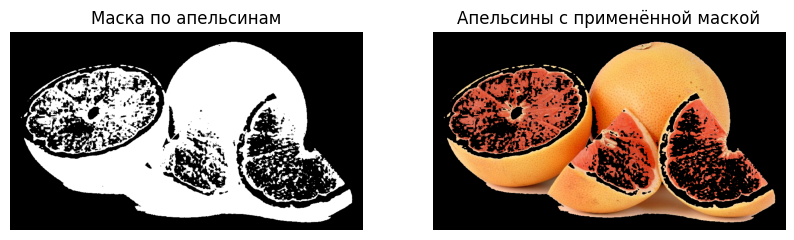

In [29]:
lower_orange = np.array([5, 80, 80])
upper_orange = np.array([25, 255, 255])

mask = cv.inRange(image_hsv, lower_orange, upper_orange)

image_with_mask = cv.bitwise_and(image_rgb, image_rgb, mask=mask)

plt.figure(figsize=(10, 6))
plt.subplot(gs[0])
plt.title("Маска по апельсинам")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(gs[1])
plt.title("Апельсины с применённой маской")
plt.imshow(image_with_mask)
plt.axis("off")
plt.show()

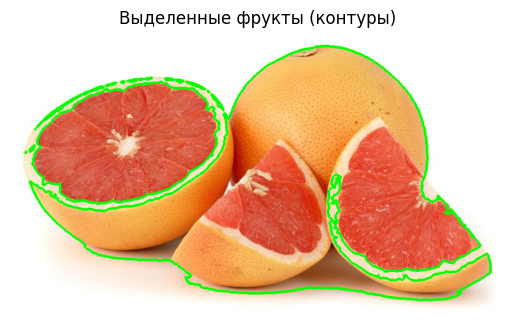

In [30]:
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

output = image_rgb.copy()
for cnt in contours:
    cv.drawContours(output, [cnt], -1, (0, 255, 0), 3)

plt.figure()
plt.title("Выделенные фрукты (контуры)")
plt.imshow(output)
plt.axis("off")
plt.show()